<a href="https://colab.research.google.com/github/abhishekhkumarsharma/Assignment_Solutions.ipynb/blob/main/%20Data%20Analysis%20Project%20for%20CV%3A%20Data%20Cleaning%2C%20Preprocessing%2C%20and%20EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Analysis Project for CV: Data Cleaning, Preprocessing, EDA, and Machine Learning for Predictive Analysis

This project showcases a complete data analysis pipeline, from initial data loading and cleaning to exploratory data analysis (EDA) and finally, building a basic machine learning model for predictive analysis. The goal is to demonstrate proficiency in using Python libraries such as pandas, numpy, scikit-learn, matplotlib, and seaborn for a structured data science workflow.

## 1. Data Loading

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Define a path for the dummy CSV file
dummy_file_path = '/tmp/data.csv'

# Always create the dummy CSV file to ensure all columns are present
print("Creating dummy CSV file...")
# Generate some dummy data for the project
data = {
    'numerical_feature_1': np.random.randint(1, 100, 100), # Numerical feature
    'numerical_feature_2': np.random.rand(100) * 100,      # Another numerical feature
    'categorical_feature': np.random.choice(['Category A', 'Category B', 'Category C'], 100), # Categorical feature
    'date_feature': pd.to_datetime(pd.date_range(start='2023-01-01', periods=100, freq='D')), # Date feature
    'target_variable': np.random.rand(100) * 200 + 50,     # Target variable (numerical)
    'missing_feature': [np.nan if i % 10 == 0 else x for i, x in enumerate(np.random.rand(100) * 50)] # Feature with missing values
}
dummy_df = pd.DataFrame(data)

# Introduce some intentional NaN values to categorical_feature for cleaning demo
# dummy_df.loc[dummy_df.sample(frac=0.05).index, 'categorical_feature'] = np.nan

dummy_df.to_csv(dummy_file_path, index=False)
print(f"Dummy CSV file created at {dummy_file_path}")

# Load the data into a pandas DataFrame
df = pd.read_csv(dummy_file_path)

print("\nFirst 5 rows of the dataset:")
display(df.head())

Creating dummy CSV file...
Dummy CSV file created at /tmp/data.csv

First 5 rows of the dataset:


,numerical_feature_1,numerical_feature_2,categorical_feature,date_feature,target_variable,missing_feature
0,4,39.694926,Category C,2023-01-01,139.885975,NaN
1,84,4.272368,Category A,2023-01-02,169.423405,34.984380
2,93,93.174243,Category C,2023-01-03,72.932422,27.661011
3,41,66.421487,Category C,2023-01-04,160.408701,47.428121
4,83,78.878302,Category B,2023-01-05,67.188624,19.941921


## 2. Data Understanding

Before any processing, it's vital to inspect the dataset's structure, data types, and summary statistics to identify potential issues and plan cleaning strategies.

In [49]:
print("### DataFrame Information (Data Types and Non-Null Counts) ###")
df.info()

print("\n### Descriptive Statistics for Numerical Columns ###")
display(df.describe())

### DataFrame Information (Data Types and Non-Null Counts) ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   numerical_feature_1  100 non-null    int64  
 1   numerical_feature_2  100 non-null    float64
 2   categorical_feature  100 non-null    object 
 3   date_feature         100 non-null    object 
 4   target_variable      100 non-null    float64
 5   missing_feature      90 non-null     float64
dtypes: float64(3), int64(1), object(2)
memory usage: 4.8+ KB

### Descriptive Statistics for Numerical Columns ###


,numerical_feature_1,numerical_feature_2,target_variable,missing_feature
count,100.000000,100.000000,100.000000,90.000000
mean,48.040000,49.026640,152.584805,26.448322
std,28.725071,30.358392,55.566841,15.304250
min,1.000000,1.096469,55.013616,0.330097
25%,23.000000,21.622307,106.018075,12.778511
50%,48.500000,44.985722,155.258514,28.988596
75%,71.250000,76.913875,201.578026,38.615602
max,99.000000,99.764394,246.261663,49.858376


## 3. Data Cleaning and Preprocessing

This phase focuses on ensuring data quality and preparing features for analysis and machine learning. It typically involves handling missing values, correcting data types, and encoding categorical variables.

In [50]:
print("### Checking for Missing Values ###")
print(df.isnull().sum())

print("\n### Handling Missing Values (Example: Imputation) ###")
# For 'missing_feature', we'll fill NaN values with the mean for numerical imputation.
# This is a simple strategy; more advanced methods might be used depending on the data.
if 'missing_feature' in df.columns:
    df['missing_feature'] = df['missing_feature'].fillna(df['missing_feature'].mean())
    print("Missing values in 'missing_feature' filled with mean.")

print("\nMissing values after imputation:")
print(df.isnull().sum())

print("\n### Data Type Conversion (Example: 'date_feature') ###")
# Ensure 'date_feature' is a datetime object
df['date_feature'] = pd.to_datetime(df['date_feature'])
print("Data type of 'date_feature' after conversion:", df['date_feature'].dtype)

print("\nDataFrame info after cleaning and preprocessing:")
df.info()

### Checking for Missing Values ###
numerical_feature_1     0
numerical_feature_2     0
categorical_feature     0
date_feature            0
target_variable         0
missing_feature        10
dtype: int64

### Handling Missing Values (Example: Imputation) ###
Missing values in 'missing_feature' filled with mean.

Missing values after imputation:
numerical_feature_1    0
numerical_feature_2    0
categorical_feature    0
date_feature           0
target_variable        0
missing_feature        0
dtype: int64

### Data Type Conversion (Example: 'date_feature') ###
Data type of 'date_feature' after conversion: datetime64[ns]

DataFrame info after cleaning and preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   numerical_feature_1  100 non-null    int64         
 1   numerical_feature_2  100 non-null    float6

## 4. Exploratory Data Analysis (EDA)

EDA helps in understanding data distributions, relationships between variables, and identifying patterns or anomalies through statistical graphics and visualization techniques.

### Distribution of Numerical Features (Histograms) ###


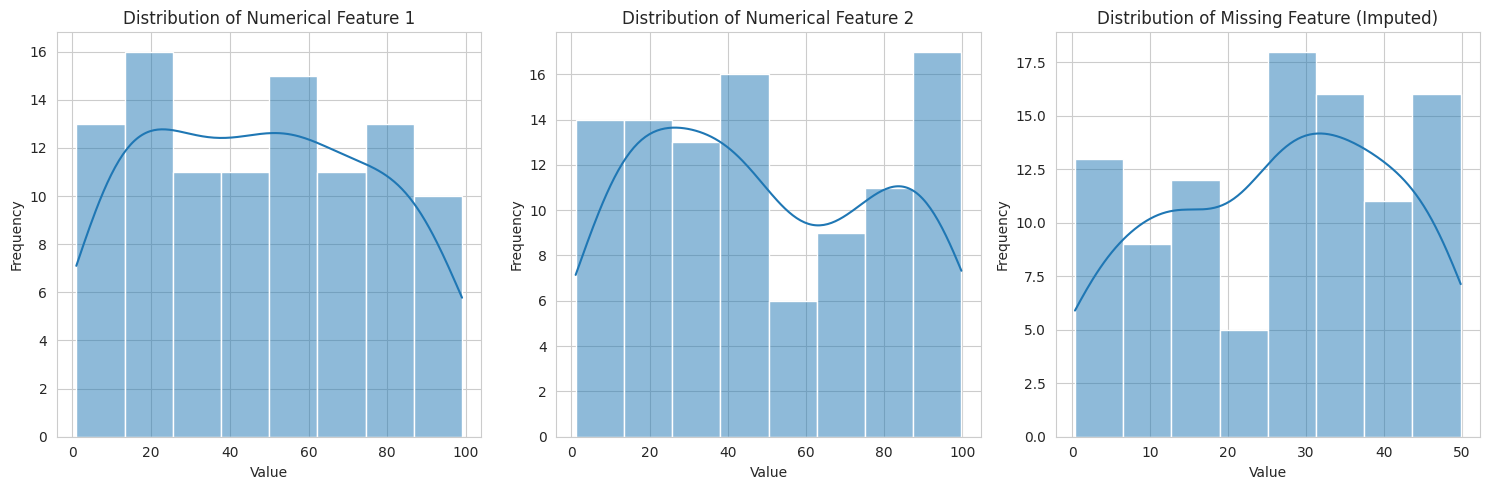


### Distribution of Categorical Feature (Count Plot) ###


/tmp/ipykernel_17878/72729086.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='categorical_feature', data=df, palette='viridis')


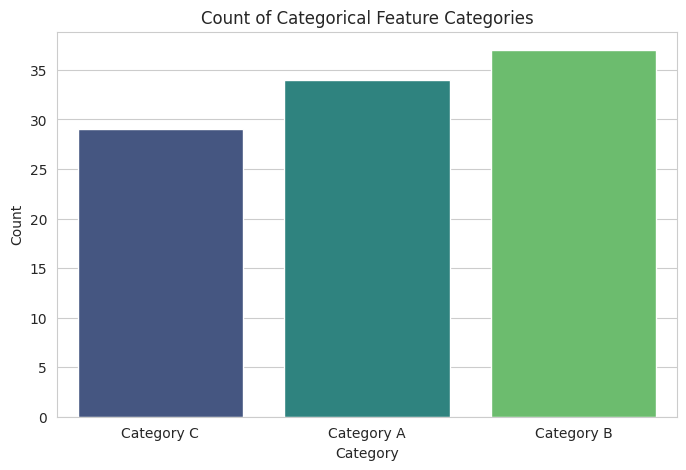

In [51]:
print("### Distribution of Numerical Features (Histograms) ###")
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['numerical_feature_1'], kde=True)
plt.title('Distribution of Numerical Feature 1')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(df['numerical_feature_2'], kde=True)
plt.title('Distribution of Numerical Feature 2')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.histplot(df['missing_feature'], kde=True)
plt.title('Distribution of Missing Feature (Imputed)')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

print("\n### Distribution of Categorical Feature (Count Plot) ###")
if 'categorical_feature' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(x='categorical_feature', data=df, palette='viridis')
    plt.title('Count of Categorical Feature Categories')
    plt.xlabel('Category')
    plt.ylabel('Count')
    plt.show()


### Relationship between Features and Target (Scatter Plots) ###


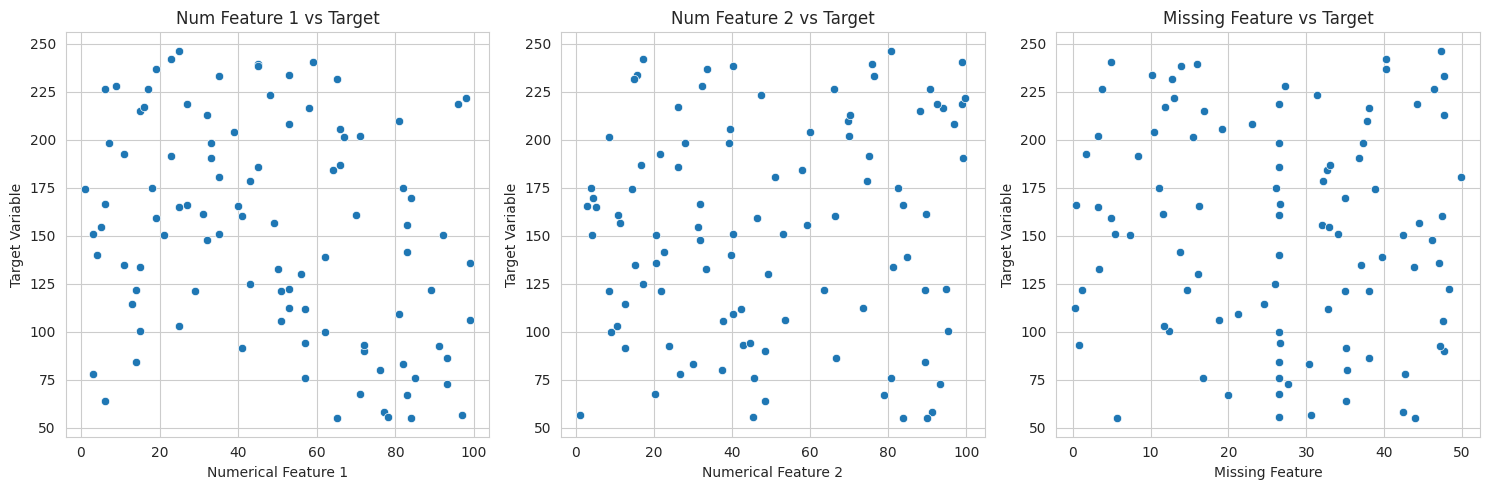

In [52]:
print("\n### Relationship between Features and Target (Scatter Plots) ###")
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='numerical_feature_1', y='target_variable', data=df)
plt.title('Num Feature 1 vs Target')
plt.xlabel('Numerical Feature 1')
plt.ylabel('Target Variable')
plt.grid(True)

plt.subplot(1, 3, 2)
sns.scatterplot(x='numerical_feature_2', y='target_variable', data=df)
plt.title('Num Feature 2 vs Target')
plt.xlabel('Numerical Feature 2')
plt.ylabel('Target Variable')
plt.grid(True)

plt.subplot(1, 3, 3)
sns.scatterplot(x='missing_feature', y='target_variable', data=df)
plt.title('Missing Feature vs Target')
plt.xlabel('Missing Feature')
plt.ylabel('Target Variable')
plt.grid(True)

plt.tight_layout()
plt.show()


### Time Series Trend (Date Feature vs Target) ###


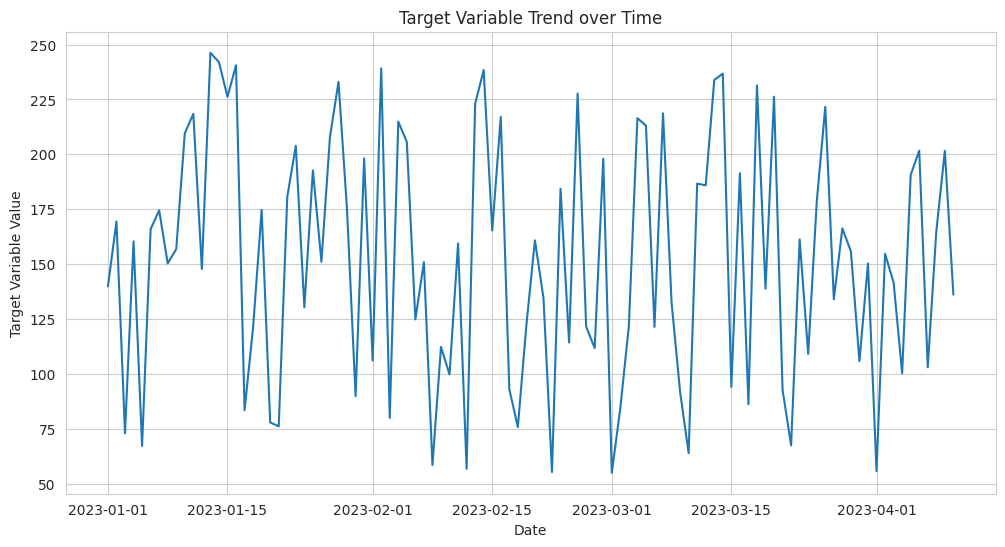

In [53]:
print("\n### Time Series Trend (Date Feature vs Target) ###")
# For date_feature, let's visualize the target_variable's trend over time
plt.figure(figsize=(12, 6))
sns.lineplot(x='date_feature', y='target_variable', data=df)
plt.title('Target Variable Trend over Time')
plt.xlabel('Date')
plt.ylabel('Target Variable Value')
plt.grid(True)
plt.show()

## 5. Machine Learning for Predictive Analysis

This section demonstrates the application of a basic machine learning model to predict the `target_variable`. The process includes preparing features, splitting data, training a model, and evaluating its performance.

### 5.1 Feature Engineering and Data Preparation for ML

In [55]:
# Define features (X) and target (y)
# Drop date_feature for now as it needs more complex feature engineering for ML
X = df[['numerical_feature_1', 'numerical_feature_2', 'categorical_feature', 'missing_feature']].copy()
y = df['target_variable'].copy()

# Identify numerical and categorical features
numerical_cols = ['numerical_feature_1', 'numerical_feature_2', 'missing_feature']
categorical_cols = ['categorical_feature']

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')) # Impute numerical missing values (though 'missing_feature' was already imputed)
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # One-hot encode categorical features
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

print("Features (X) and Target (y) defined and preprocessor pipeline created.")

Features (X) and Target (y) defined and preprocessor pipeline created.


### 5.2 Data Splitting

In [56]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 80 samples
Testing set size: 20 samples


### 5.3 Model Selection and Training

In [57]:
# Create a full pipeline including preprocessing and the model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression()) # Using Linear Regression as a basic predictive model
])

# Train the model
model_pipeline.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


### 5.4 Model Evaluation

Mean Absolute Error (MAE): 49.19
Mean Squared Error (MSE): 3025.08
Root Mean Squared Error (RMSE): 55.00
R-squared (R2): 0.15


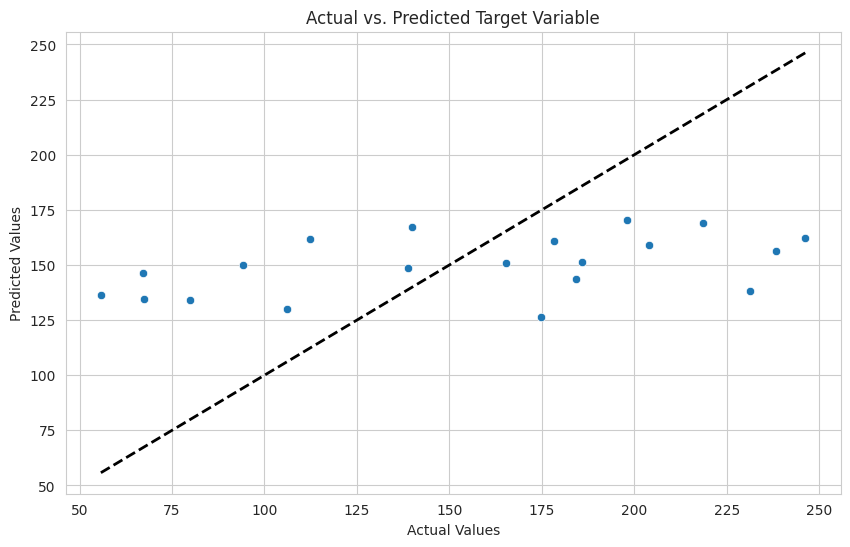

In [58]:
# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Plotting actual vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Diagonal line for perfect prediction
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Target Variable')
plt.grid(True)
plt.show()